In [1]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Indian Population Dataset.xlsx")

df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          10 non-null     object 
 1   Region         10 non-null     object 
 2   Population     10 non-null     int64  
 3   Area_km2       10 non-null     int64  
 4   Literacy_Rate  10 non-null     float64
 5   Density        10 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 612.0+ bytes


In [5]:
df.describe()

,Population,Area_km2,Literacy_Rate,Density
count,1.000000e+01,10.000000,10.000000,10.000000
mean,7.683833e+07,161629.000000,53.065000,564.200000
std,5.319551e+07,113670.107601,27.316568,216.005041
min,1.678794e+07,1484.000000,6.870000,245.000000
25%,4.188451e+07,81016.500000,31.600000,375.750000
50%,6.805556e+07,160924.500000,57.995000,560.000000
75%,8.649384e+07,229702.000000,72.877500,765.000000
max,1.998123e+08,342239.000000,90.970000,834.000000


In [6]:
df.isnull().sum()

,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [8]:
df.columns

Index(['State', 'Region', 'Population', 'Area_km2', 'Literacy_Rate',
       'Density'],
      dtype='object')

In [20]:
# Create a binary target based on Density
df["Density_Class"] = (df["Density"] > df["Density"].median()).astype(int)

# Features
X = df.drop(columns=["Density", "Density_Class"])

# Target
y = df["Density_Class"]

print(X.head())
print(y.head())

   State  Region  Population  Area_km2  Literacy_Rate
0      3       2    67562686    191791          75.86
1      7       2    72147030    130058          24.56
2      4       2    35699443     38863          21.66
3      5       3   124904071    307713          90.97
4      1       1    16787941      1484          78.09
0    1
1    0
2    0
3    1
4    1
Name: Density_Class, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear", random_state=42)

svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [24]:
svm_predictions = svm_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6666666666666666


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



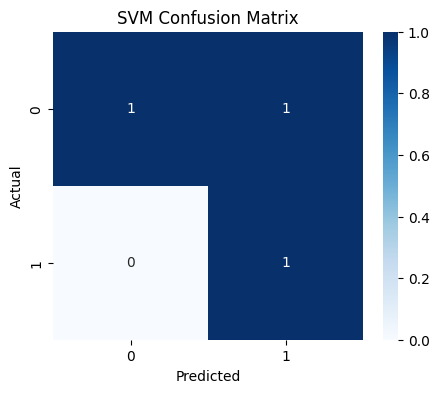

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [29]:
knn_predictions = knn_model.predict(X_test)

In [30]:
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.3333333333333333


In [37]:
print(classification_report(y_test, knn_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



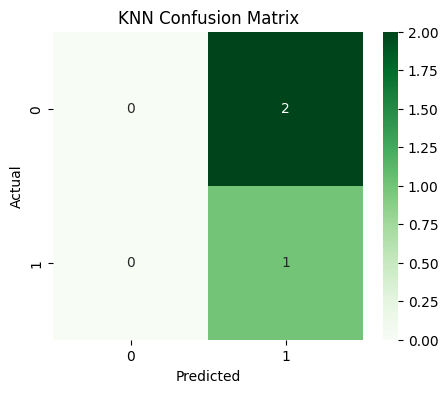

In [32]:
cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [33]:
comparison = pd.DataFrame({
    "Model": ["SVM", "KNN"],
    "Accuracy": [svm_accuracy, knn_accuracy]
})

print(comparison)

  Model  Accuracy
0   SVM  0.666667
1   KNN  0.333333


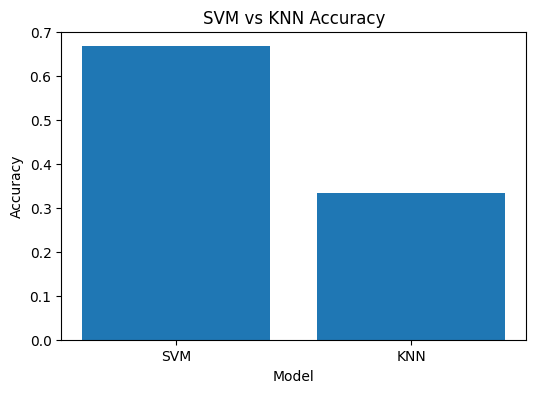

In [36]:
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("SVM vs KNN Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

print("✔ Dataset Loaded")
print("✔ Missing Values Checked")
print("✔ Features Encoded")
print("✔ Train/Test Split Completed")
print("✔ Feature Scaling Done")
print("✔ SVM Model Trained")
print("✔ KNN Model Trained")
print("✔ Accuracy Compared")
print("✔ Confusion Matrices Generated")